In [1]:
# Interpolate population by decade to annual population

In [8]:
import xarray as xr

In [2]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

In [3]:
population_decade = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000-2100.nc")

In [4]:
# Create range of dates [2000, 2001, 2002, ..., 2100]
annual_range = range(population_decade.year[0].values, (population_decade.year[-1]+1).values, 1)

# Interpolate across years
annual_population = population_decade.interp(year=annual_range)

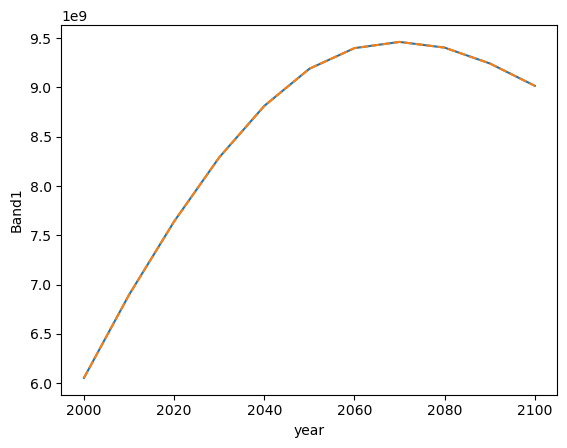

In [7]:
# Test interpolation
population_decade.sum(dim=("lat", "lon")).plot()
annual_population.sum(dim=("lat", "lon")).plot(linestyle="--")

In [17]:
annual_population.to_netcdf(f"{POP_DIR}ssp2_total_regrid_annual_2000-2100.nc")